# 20_analysis_deeponet_fno.ipynb

Аналитический ноутбук для сравнения **DeepONet v2** и **FNO v1** на `test`-наборе `usct_dataset_v2`.

## Что делает ноутбук
- загружает уже обученные **DeepONet v2** и **FNO v1**;
- считает per-sample предсказания на `test`;
- строит таблицу per-sample метрик;
- показывает:
  - распределение RMSE / relative L2 / PSNR,
  - scatter `DeepONet error vs FNO error`,
  - где какая модель выигрывает,
  - best / worst test cases,
  - hardest cases для обеих моделей,
  - связь ошибки с характеристиками target-map и measurement tensor.

## Зачем
Это ноутбук не для обучения, а для **исследовательских выводов**:
- понять, где именно DeepONet сильнее FNO;
- насколько различаются хвосты ошибок;
- от каких свойств объекта / измерений зависит качество;
- какие qualitative failure modes у моделей.

## 0. Важно
`M_hom` считается через `j-Wave`, поэтому JAX запускается на **CPU**.

Обе модели используются только в режиме **inference**.

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64'

In [2]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import json
import math
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu130
cuda available: True
device name: NVIDIA GeForce RTX 5090


In [4]:
CFG = {
    "dataset_root": "/workspace/usct_dataset_v2",
    "deeponet_ckpt": "/workspace/reference_points/deeponet_v2_main/deeponet_best.pt",
    "fno_ckpt": "/workspace/reference_points/fno_v1/fno_best.pt",
    "run_name": "analysis_deeponet_fno",
    "mask_half_width": 2,
    "use_residual": True,
    "top_k_cases": 8,
}
CFG

{'dataset_root': '/workspace/usct_dataset_v2',
 'deeponet_ckpt': '/workspace/reference_points/deeponet_v2_main/deeponet_best.pt',
 'fno_ckpt': '/workspace/reference_points/fno_v1/fno_best.pt',
 'run_name': 'analysis_deeponet_fno',
 'mask_half_width': 2,
 'use_residual': True,
 'top_k_cases': 8}

In [5]:
OUT_ROOT = Path(CFG["dataset_root"])
TEST_DIR = OUT_ROOT / "test"
DEEPO_CKPT_PATH = Path(CFG["deeponet_ckpt"])
FNO_CKPT_PATH = Path(CFG["fno_ckpt"])

assert TEST_DIR.exists(), TEST_DIR
assert DEEPO_CKPT_PATH.exists(), DEEPO_CKPT_PATH
assert FNO_CKPT_PATH.exists(), FNO_CKPT_PATH

test_files = sorted(TEST_DIR.glob("*.npz"))

print("test:", len(test_files))
print("DeepONet ckpt:", DEEPO_CKPT_PATH)
print("FNO ckpt:", FNO_CKPT_PATH)

test: 800
DeepONet ckpt: /workspace/reference_points/deeponet_v2_main/deeponet_best.pt
FNO ckpt: /workspace/reference_points/fno_v1/fno_best.pt


In [6]:
sample0 = np.load(test_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

train_dir = OUT_ROOT / "train"
all_c_values = []
for p in sorted(train_dir.glob("*.npz")):
    c = np.load(p)["c"].astype(np.float32)
    all_c_values.append(c)
all_c_values = np.stack(all_c_values, axis=0)

stats = {
    "c_min": float(all_c_values.min()),
    "c_max": float(all_c_values.max()),
}
print("S, R:", S, R)
print("H, W:", H, W)
print("dx:", dx)
print("freq_hz:", freq_hz)
print("stats:", stats)

S, R: 16 256
H, W: 192 192
dx: (np.float32(0.00075), np.float32(0.00075))
freq_hz: 500000.0
stats: {'c_min': 1404.1473388671875, 'c_max': 1598.34423828125}


## 1. `M_hom` через j-Wave

In [7]:
import jax
import jax.numpy as jnp
from jax import jit

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CudaDevice(id=0)]


In [8]:
domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

def gaussian_source(H, W, y0, x0, sigma=1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

full_source_fields = []
for ridx in source_ring_idx_full:
    y0 = int(receiver_y[ridx])
    x0 = int(receiver_x[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=1.8)
    full_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
full_source_fields = tuple(full_source_fields)

def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(domain=domain, sound_speed=sound_speed, density=1000.0, pml_size=16)
    return medium

def forward_measurements_full(c_map):
    medium = make_medium(c_map)
    ms = []
    for i in range(len(full_source_fields)):
        src = FourierSeries(jnp.expand_dims(full_source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y, receiver_x])
    return jnp.stack(ms, axis=0)

forward_measurements_full_jit = jit(forward_measurements_full)

/tmp/ipykernel_7331/1657452440.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


In [9]:
c_hom = jnp.full((H, W), 1500.0, dtype=jnp.float32)

t0 = time.time()
M_hom_complex = forward_measurements_full_jit(c_hom)
M_hom_complex.block_until_ready()
t1 = time.time()

M_hom_complex = np.array(M_hom_complex)

print("M_hom_complex:", M_hom_complex.shape, M_hom_complex.dtype)
print("time:", t1 - t0, "sec")

M_hom_complex: (16, 256) complex64
time: 6.329032897949219 sec


## 2. Dataset

In [10]:
def mask_self_receivers(M, source_ring_idx, half_width=2):
    M = M.copy()
    S_local, R_local = M.shape
    for s in range(S_local):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % R_local
            M[s, rr] = 0.0 + 0.0j
    return M

class USCTAnalysisDataset(Dataset):
    def __init__(self, paths, c_min, c_max, M_hom_complex, use_residual=True, mask_half_width=2):
        self.paths = list(paths)
        self.c_min = float(c_min)
        self.c_max = float(c_max)
        self.c_range = max(self.c_max - self.c_min, 1e-8)
        self.M_hom_complex = M_hom_complex
        self.use_residual = bool(use_residual)
        self.mask_half_width = int(mask_half_width)

    def __len__(self):
        return len(self.paths)

    def normalize_target(self, c):
        return 2.0 * (c - self.c_min) / self.c_range - 1.0

    def denormalize_target(self, c_norm):
        return ((c_norm + 1.0) * 0.5) * self.c_range + self.c_min

    def __getitem__(self, idx):
        d = np.load(self.paths[idx])

        x_raw = d["x"].astype(np.float32)
        c = d["c"].astype(np.float32)
        source_ring_idx = d["source_ring_idx"].astype(np.int64)

        M = x_raw[0] + 1j * x_raw[1]

        if self.use_residual:
            M = M - self.M_hom_complex

        if self.mask_half_width > 0:
            M = mask_self_receivers(M, source_ring_idx, half_width=self.mask_half_width)

        x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)

        x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
        if x_scale < 1e-8:
            x_scale = 1.0
        x_tensor = x_tensor / x_scale

        c_norm = self.normalize_target(c).astype(np.float32)

        return (
            torch.from_numpy(x_tensor),
            torch.from_numpy(c_norm).unsqueeze(0),
            {"path": str(self.paths[idx]), "x_scale": x_scale},
        )

In [11]:
ds_test = USCTAnalysisDataset(
    test_files,
    stats["c_min"],
    stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)

x0, c0, meta0 = ds_test[0]
print("x0:", x0.shape, x0.dtype)
print("c0:", c0.shape, c0.dtype, float(c0.min()), float(c0.max()))
print(meta0)

x0: torch.Size([2, 16, 256]) torch.float32
c0: torch.Size([1, 192, 192]) torch.float32 -0.7432032227516174 0.5520349740982056
{'path': '/workspace/usct_dataset_v2/test/sample_00000.npz', 'x_scale': 5060.05078125}


## 3. Load model definitions and checkpoints

In [12]:
class BranchEncoderV2(nn.Module):
    def __init__(self, out_dim=192, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(1, 32),
            nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 64),
            nn.GELU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 128),
            nn.GELU(),
            nn.Conv2d(128, 192, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 192),
            nn.GELU(),
            nn.Flatten(),
            nn.Linear(192 * 2 * 32, 384),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(384, out_dim),
        )
    def forward(self, x):
        return self.net(x)

class TrunkNetV2(nn.Module):
    def __init__(self, width=192, hidden=256, num_fourier_features=24, dropout=0.0):
        super().__init__()
        self.num_fourier_features = int(num_fourier_features)
        if self.num_fourier_features > 0:
            freq = 2.0 ** torch.arange(self.num_fourier_features, dtype=torch.float32) * math.pi
            self.register_buffer("freq", freq, persistent=False)
            in_dim = 2 + 4 * self.num_fourier_features
        else:
            self.register_buffer("freq", torch.empty(0), persistent=False)
            in_dim = 2

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, width),
        )

    def encode_coords(self, coords):
        if self.num_fourier_features == 0:
            return coords

        y = coords[:, 0:1]
        x = coords[:, 1:2]
        y_proj = y * self.freq[None, :]
        x_proj = x * self.freq[None, :]

        feats = [
            coords,
            torch.sin(y_proj),
            torch.cos(y_proj),
            torch.sin(x_proj),
            torch.cos(x_proj),
        ]
        return torch.cat(feats, dim=1)

    def forward(self, coords):
        return self.net(self.encode_coords(coords))

class DeepONet2DV2(nn.Module):
    def __init__(self, branch_width=192, trunk_width=192, trunk_hidden=256, num_fourier_features=24, dropout=0.0):
        super().__init__()
        self.width = int(branch_width)
        self.branch = BranchEncoderV2(out_dim=branch_width, dropout=dropout)
        self.trunk = TrunkNetV2(
            width=trunk_width,
            hidden=trunk_hidden,
            num_fourier_features=num_fourier_features,
            dropout=dropout,
        )
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x, coords):
        b = self.branch(x)
        t = self.trunk(coords)
        out = torch.matmul(b, t.t()) / math.sqrt(self.width) + self.bias
        return out.view(x.shape[0], 1, H, W)

In [13]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        scale = 1 / (in_channels * out_channels)
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.weights1 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        x = x.float()
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)

        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-2),
            x.size(-1) // 2 + 1,
            dtype=torch.cfloat,
            device=x.device,
        )

        out_ft[:, :, : self.modes1, : self.modes2] = self.compl_mul2d(
            x_ft[:, :, : self.modes1, : self.modes2], self.weights1
        )
        out_ft[:, :, -self.modes1 :, : self.modes2] = self.compl_mul2d(
            x_ft[:, :, -self.modes1 :, : self.modes2], self.weights2
        )

        return torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

class FNOBlock2d(nn.Module):
    def __init__(self, width, modes1, modes2):
        super().__init__()
        self.spectral = SpectralConv2d(width, width, modes1, modes2)
        self.pointwise = nn.Conv2d(width, width, kernel_size=1)
    def forward(self, x):
        return F.gelu(self.spectral(x) + self.pointwise(x))

class FNO2dBaseline(nn.Module):
    def __init__(self, width=48, depth=4, modes1=24, modes2=24, padding=8):
        super().__init__()
        self.padding = padding
        self.input_proj = nn.Conv2d(4, width, kernel_size=1)
        self.blocks = nn.ModuleList([FNOBlock2d(width, modes1, modes2) for _ in range(depth)])
        self.head = nn.Sequential(
            nn.Conv2d(width, width, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(width, 1, kernel_size=1),
        )

    def get_grid(self, batch_size, device):
        yy = torch.linspace(-1.0, 1.0, H, device=device)
        xx = torch.linspace(-1.0, 1.0, W, device=device)
        gy, gx = torch.meshgrid(yy, xx, indexing="ij")
        return torch.stack([gy, gx], dim=0).unsqueeze(0).repeat(batch_size, 1, 1, 1)

    def forward(self, x):
        x = F.interpolate(x, size=(H, W), mode="bilinear", align_corners=False)
        grid = self.get_grid(x.shape[0], x.device)
        x = torch.cat([x, grid], dim=1)
        x = self.input_proj(x)

        if self.padding > 0:
            x = F.pad(x, [0, self.padding, 0, self.padding])

        for block in self.blocks:
            x = block(x)

        if self.padding > 0:
            x = x[..., :H, :W]

        return self.head(x)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

deeponet_ckpt = torch.load(DEEPO_CKPT_PATH, map_location=device)
fno_ckpt = torch.load(FNO_CKPT_PATH, map_location=device)

deeponet_cfg = deeponet_ckpt["config"]
fno_cfg = fno_ckpt["config"]

yy = np.linspace(-1.0, 1.0, H, dtype=np.float32)
xx = np.linspace(-1.0, 1.0, W, dtype=np.float32)
grid_y, grid_x = np.meshgrid(yy, xx, indexing="ij")
coords = np.stack([grid_y, grid_x], axis=-1).reshape(-1, 2)
coords_t = torch.from_numpy(coords).to(device)

deeponet = DeepONet2DV2(
    branch_width=deeponet_cfg["branch_width"],
    trunk_width=deeponet_cfg["trunk_width"],
    trunk_hidden=deeponet_cfg["trunk_hidden"],
    num_fourier_features=deeponet_cfg["num_fourier_features"],
    dropout=deeponet_cfg["dropout"],
).to(device)
deeponet.load_state_dict(deeponet_ckpt["model_state_dict"], strict=True)
deeponet.eval()

fno = FNO2dBaseline(
    width=fno_cfg["fno_width"],
    depth=fno_cfg["fno_depth"],
    modes1=fno_cfg["fno_modes_h"],
    modes2=fno_cfg["fno_modes_w"],
    padding=fno_cfg["fno_padding"],
).to(device)
fno.load_state_dict(fno_ckpt["model_state_dict"], strict=True)
fno.eval()

print("DeepONet best epoch:", deeponet_ckpt.get("best_epoch"))
print("FNO best epoch:", fno_ckpt.get("best_epoch"))

DeepONet best epoch: 197
FNO best epoch: 159


## 4. Cache predictions and sample-level descriptors

In [15]:
def denorm_c_from_minus1_1(c_norm, c_min, c_max):
    return ((c_norm + 1.0) * 0.5) * (c_max - c_min) + c_min

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    ssim_fn = None

def mse(a, b):
    return float(np.mean((a - b) ** 2))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def relative_l2(a, b):
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-8))

def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

def compute_metrics(pred, target, data_range):
    out = {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }
    if HAS_SKIMAGE:
        out["ssim"] = float(ssim_fn(pred, target, data_range=data_range))
    return out

@torch.no_grad()
def collect_all_outputs(dataset):
    rows = []
    predictions = []

    data_range = float(stats["c_max"] - stats["c_min"])

    for idx in range(len(dataset)):
        x, c, meta = dataset[idx]
        xb = x.unsqueeze(0).to(device)

        pred_deepo = deeponet(xb, coords_t)[0, 0].cpu().numpy()
        pred_fno = fno(xb)[0, 0].cpu().numpy()

        pred_deepo = np.clip(pred_deepo, -1.0, 1.0)
        pred_fno = np.clip(pred_fno, -1.0, 1.0)
        target = c[0].numpy()

        pred_deepo_phys = denorm_c_from_minus1_1(pred_deepo, stats["c_min"], stats["c_max"])
        pred_fno_phys = denorm_c_from_minus1_1(pred_fno, stats["c_min"], stats["c_max"])
        target_phys = denorm_c_from_minus1_1(target, stats["c_min"], stats["c_max"])

        metrics_deepo = compute_metrics(pred_deepo_phys, target_phys, data_range)
        metrics_fno = compute_metrics(pred_fno_phys, target_phys, data_range)

        d = np.load(meta["path"])
        x_raw = d["x"].astype(np.float32)
        M_complex = x_raw[0] + 1j * x_raw[1]
        amp = np.abs(M_complex)
        phase = np.angle(M_complex)

        disagreement_l2 = float(np.linalg.norm(pred_deepo_phys - pred_fno_phys) / (np.linalg.norm(target_phys) + 1e-8))
        disagreement_rmse = float(np.sqrt(np.mean((pred_deepo_phys - pred_fno_phys) ** 2)))

        row = {
            "index": idx,
            "path": meta["path"],

            "deepo_mse": metrics_deepo["mse"],
            "deepo_rmse": metrics_deepo["rmse"],
            "deepo_relative_l2": metrics_deepo["relative_l2"],
            "deepo_psnr": metrics_deepo["psnr"],

            "fno_mse": metrics_fno["mse"],
            "fno_rmse": metrics_fno["rmse"],
            "fno_relative_l2": metrics_fno["relative_l2"],
            "fno_psnr": metrics_fno["psnr"],

            "rmse_gap_fno_minus_deepo": metrics_fno["rmse"] - metrics_deepo["rmse"],
            "relative_l2_gap_fno_minus_deepo": metrics_fno["relative_l2"] - metrics_deepo["relative_l2"],
            "psnr_gap_deepo_minus_fno": metrics_deepo["psnr"] - metrics_fno["psnr"],

            "winner_by_rmse": "DeepONet" if metrics_deepo["rmse"] < metrics_fno["rmse"] else "FNO",
            "disagreement_rmse": disagreement_rmse,
            "disagreement_relative_l2": disagreement_l2,

            "c_min": float(target_phys.min()),
            "c_max": float(target_phys.max()),
            "c_mean": float(target_phys.mean()),
            "c_std": float(target_phys.std()),
            "c_range": float(target_phys.max() - target_phys.min()),

            "amp_mean": float(amp.mean()),
            "amp_std": float(amp.std()),
            "amp_max": float(amp.max()),
            "amp_p95": float(np.percentile(amp, 95)),
            "phase_mean": float(phase.mean()),
            "phase_std": float(phase.std()),
            "x_scale": float(meta["x_scale"]),
        }

        if "ssim" in metrics_deepo:
            row["deepo_ssim"] = metrics_deepo["ssim"]
            row["fno_ssim"] = metrics_fno["ssim"]
            row["ssim_gap_deepo_minus_fno"] = metrics_deepo["ssim"] - metrics_fno["ssim"]

        rows.append(row)
        predictions.append({
            "index": idx,
            "path": meta["path"],
            "target_phys": target_phys.astype(np.float32),
            "deepo_pred_phys": pred_deepo_phys.astype(np.float32),
            "fno_pred_phys": pred_fno_phys.astype(np.float32),
            "deepo_abs_err": np.abs(pred_deepo_phys - target_phys).astype(np.float32),
            "fno_abs_err": np.abs(pred_fno_phys - target_phys).astype(np.float32),
        })

    return pd.DataFrame(rows), predictions

df_test, predictions_test = collect_all_outputs(ds_test)
print(df_test.shape)
df_test.head()

(800, 28)


,index,path,deepo_mse,deepo_rmse,deepo_relative_l2,deepo_psnr,fno_mse,fno_rmse,fno_relative_l2,fno_psnr,...,c_mean,c_std,c_range,amp_mean,amp_std,amp_max,amp_p95,phase_mean,phase_std,x_scale
0,0,/workspace/usct_dataset_v2/test/sample_00000.npz,258.718323,16.084723,0.010799,21.636574,389.036011,19.723995,0.013242,19.864948,...,1489.302124,25.948122,125.765625,5472.236328,23337.917969,300205.37500,8510.636719,0.026127,1.819186,5060.050781
1,1,/workspace/usct_dataset_v2/test/sample_00001.npz,289.007996,17.000235,0.011431,21.155747,460.918457,21.469011,0.014436,19.128605,...,1486.957275,28.412287,124.658325,5426.809082,23360.998047,300549.00000,8468.890625,-0.009712,1.828317,6126.951172
2,2,/workspace/usct_dataset_v2/test/sample_00002.npz,399.036407,19.975895,0.013463,19.754721,588.850159,24.266235,0.016355,18.064798,...,1483.394775,30.928501,122.967896,5425.446289,23431.998047,309637.03125,8557.118164,-0.045534,1.828695,6959.107422
3,3,/workspace/usct_dataset_v2/test/sample_00003.npz,289.355988,17.010468,0.011438,21.150521,460.697815,21.463873,0.014432,19.130684,...,1486.986938,28.020378,118.312866,5445.663086,23344.044922,300216.40625,8449.416016,-0.030439,1.837594,5577.994141
4,4,/workspace/usct_dataset_v2/test/sample_00004.npz,315.485962,17.761925,0.011959,20.775045,460.719788,21.464384,0.014452,19.130477,...,1484.953125,29.321497,124.246826,5438.434082,23365.371094,300837.65625,8632.376953,-0.037229,1.821462,5747.639648


In [16]:
metric_cols = [c for c in df_test.columns if c.endswith(("rmse", "relative_l2", "psnr", "ssim")) and ("gap" not in c) and ("disagreement" not in c)]
df_test[metric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
deepo_rmse,800.0,13.830151,4.000147,6.674848,10.135611,13.883547,16.927734,23.783405
deepo_relative_l2,800.0,0.009269,0.002678,0.004468,0.006818,0.009322,0.011333,0.015915
deepo_psnr,800.0,23.338234,2.660261,18.239365,21.192869,22.914837,25.647849,29.276019
fno_rmse,800.0,17.359155,4.854176,7.863368,12.641090,17.755872,21.269320,29.532873
fno_relative_l2,800.0,0.011634,0.003251,0.005266,0.008478,0.011927,0.014242,0.019904
fno_psnr,800.0,21.347017,2.616430,16.358732,19.209776,20.778007,23.729157,27.852675


## 5. Aggregate comparison

In [17]:
def summarize_model(df, prefix):
    out = {}
    for metric in ["mse", "rmse", "relative_l2", "psnr"]:
        col = f"{prefix}_{metric}"
        out[f"{metric}_mean"] = float(df[col].mean())
        out[f"{metric}_std"] = float(df[col].std())
    if f"{prefix}_ssim" in df.columns:
        out["ssim_mean"] = float(df[f"{prefix}_ssim"].mean())
        out["ssim_std"] = float(df[f"{prefix}_ssim"].std())
    return out

summary = pd.DataFrame({
    "DeepONet": summarize_model(df_test, "deepo"),
    "FNO": summarize_model(df_test, "fno"),
}).T

summary

,mse_mean,mse_std,rmse_mean,rmse_std,relative_l2_mean,relative_l2_std,psnr_mean,psnr_std
DeepONet,207.254257,112.927956,13.830151,4.000147,0.009269,0.002678,23.338234,2.660261
FNO,324.873834,168.951623,17.359155,4.854176,0.011634,0.003251,21.347017,2.616430


In [18]:
deepo_wins = int((df_test["winner_by_rmse"] == "DeepONet").sum())
fno_wins = int((df_test["winner_by_rmse"] == "FNO").sum())

print("DeepONet wins by RMSE on", deepo_wins, "samples")
print("FNO wins by RMSE on", fno_wins, "samples")
print("Mean RMSE gap (FNO - DeepONet):", float(df_test["rmse_gap_fno_minus_deepo"].mean()))
print("Median RMSE gap (FNO - DeepONet):", float(df_test["rmse_gap_fno_minus_deepo"].median()))

DeepONet wins by RMSE on 799 samples
FNO wins by RMSE on 1 samples
Mean RMSE gap (FNO - DeepONet): 3.5290036964416505
Median RMSE gap (FNO - DeepONet): 3.683795928955078


## 6. RMSE / relative L2 / PSNR distributions

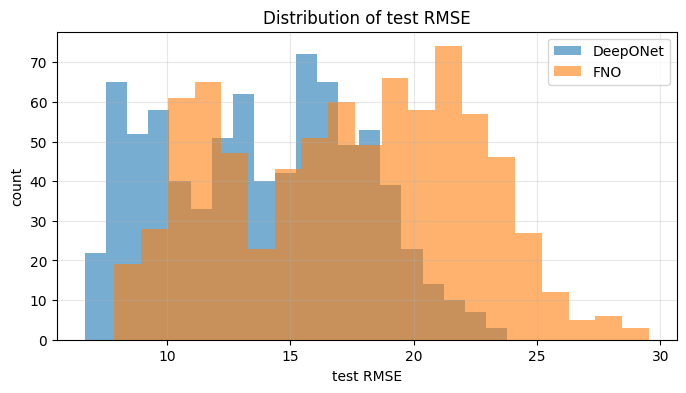

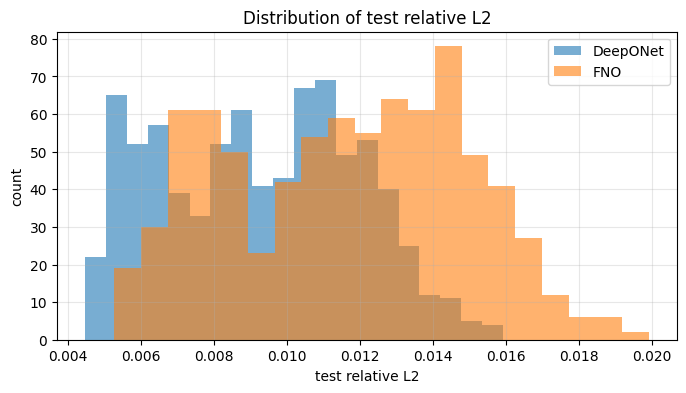

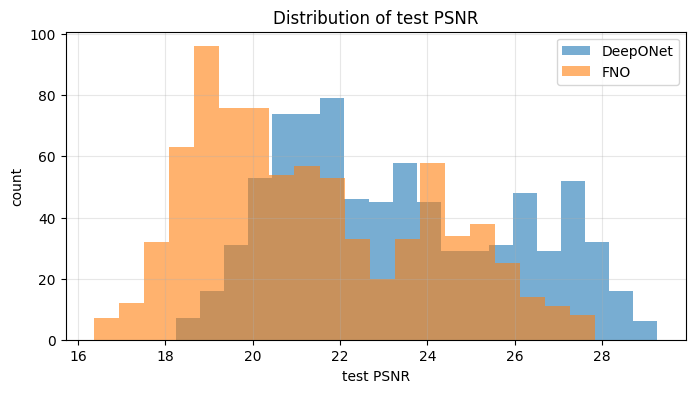

In [19]:
plt.figure(figsize=(8, 4))
plt.hist(df_test["deepo_rmse"], bins=20, alpha=0.6, label="DeepONet")
plt.hist(df_test["fno_rmse"], bins=20, alpha=0.6, label="FNO")
plt.xlabel("test RMSE")
plt.ylabel("count")
plt.title("Distribution of test RMSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df_test["deepo_relative_l2"], bins=20, alpha=0.6, label="DeepONet")
plt.hist(df_test["fno_relative_l2"], bins=20, alpha=0.6, label="FNO")
plt.xlabel("test relative L2")
plt.ylabel("count")
plt.title("Distribution of test relative L2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df_test["deepo_psnr"], bins=20, alpha=0.6, label="DeepONet")
plt.hist(df_test["fno_psnr"], bins=20, alpha=0.6, label="FNO")
plt.xlabel("test PSNR")
plt.ylabel("count")
plt.title("Distribution of test PSNR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

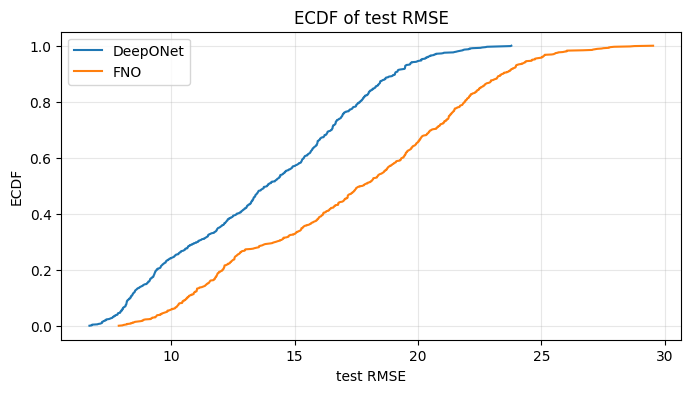

In [20]:
def plot_ecdf(values, label):
    x = np.sort(np.asarray(values))
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=label)

plt.figure(figsize=(8, 4))
plot_ecdf(df_test["deepo_rmse"], "DeepONet")
plot_ecdf(df_test["fno_rmse"], "FNO")
plt.xlabel("test RMSE")
plt.ylabel("ECDF")
plt.title("ECDF of test RMSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Direct model-vs-model comparison

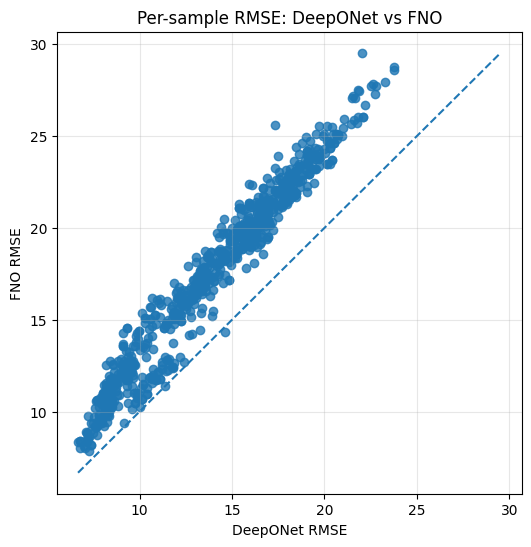

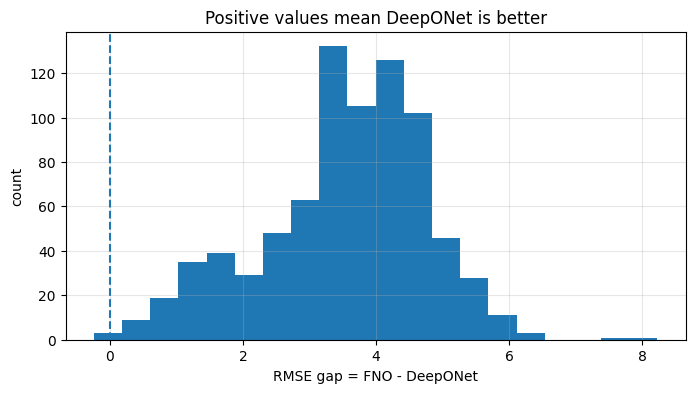

In [21]:
plt.figure(figsize=(6, 6))
plt.scatter(df_test["deepo_rmse"], df_test["fno_rmse"], alpha=0.8)
lo = min(df_test["deepo_rmse"].min(), df_test["fno_rmse"].min())
hi = max(df_test["deepo_rmse"].max(), df_test["fno_rmse"].max())
plt.plot([lo, hi], [lo, hi], linestyle="--")
plt.xlabel("DeepONet RMSE")
plt.ylabel("FNO RMSE")
plt.title("Per-sample RMSE: DeepONet vs FNO")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df_test["rmse_gap_fno_minus_deepo"], bins=20)
plt.axvline(0.0, linestyle="--")
plt.xlabel("RMSE gap = FNO - DeepONet")
plt.ylabel("count")
plt.title("Positive values mean DeepONet is better")
plt.grid(True, alpha=0.3)
plt.show()

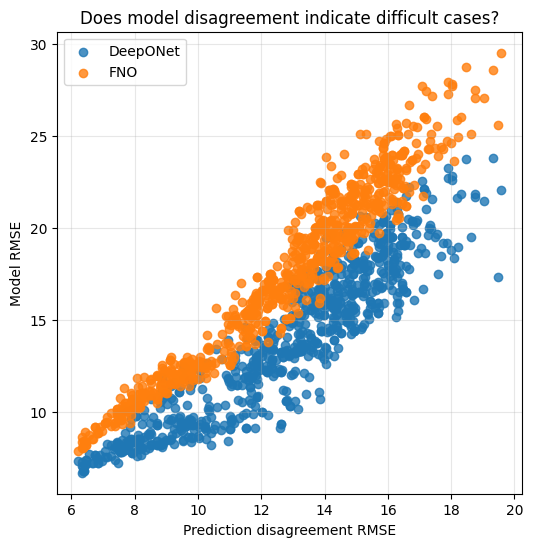

corr(disagreement_rmse, deepo_rmse) = 0.923758318524257
corr(disagreement_rmse, fno_rmse)   = 0.9697193867953159


In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(df_test["disagreement_rmse"], df_test["deepo_rmse"], alpha=0.8, label="DeepONet")
plt.scatter(df_test["disagreement_rmse"], df_test["fno_rmse"], alpha=0.8, label="FNO")
plt.xlabel("Prediction disagreement RMSE")
plt.ylabel("Model RMSE")
plt.title("Does model disagreement indicate difficult cases?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("corr(disagreement_rmse, deepo_rmse) =", float(df_test["disagreement_rmse"].corr(df_test["deepo_rmse"])))
print("corr(disagreement_rmse, fno_rmse)   =", float(df_test["disagreement_rmse"].corr(df_test["fno_rmse"])))

## 8. Best / worst / most diagnostic cases

In [23]:
TOP_K = int(CFG["top_k_cases"])

best_deepo = df_test.nsmallest(TOP_K, "deepo_rmse")[["index", "path", "deepo_rmse", "fno_rmse", "c_std", "amp_std"]]
worst_deepo = df_test.nlargest(TOP_K, "deepo_rmse")[["index", "path", "deepo_rmse", "fno_rmse", "c_std", "amp_std"]]

best_fno = df_test.nsmallest(TOP_K, "fno_rmse")[["index", "path", "deepo_rmse", "fno_rmse", "c_std", "amp_std"]]
worst_fno = df_test.nlargest(TOP_K, "fno_rmse")[["index", "path", "deepo_rmse", "fno_rmse", "c_std", "amp_std"]]

deeo_biggest_wins = df_test.nlargest(TOP_K, "rmse_gap_fno_minus_deepo")[["index", "path", "deepo_rmse", "fno_rmse", "rmse_gap_fno_minus_deepo", "c_std", "amp_std"]]
fno_biggest_wins = df_test.nsmallest(TOP_K, "rmse_gap_fno_minus_deepo")[["index", "path", "deepo_rmse", "fno_rmse", "rmse_gap_fno_minus_deepo", "c_std", "amp_std"]]

hard_for_both = df_test.assign(mean_rmse=(df_test["deepo_rmse"] + df_test["fno_rmse"]) / 2).nlargest(TOP_K, "mean_rmse")[["index", "path", "deepo_rmse", "fno_rmse", "mean_rmse", "c_std", "amp_std"]]

print("BEST DEEPONET")
display(best_deepo)

print("WORST DEEPONET")
display(worst_deepo)

print("BEST FNO")
display(best_fno)

print("WORST FNO")
display(worst_fno)

print("DEEPO BIGGEST WINS")
display(deeo_biggest_wins)

print("FNO BIGGEST WINS")
display(fno_biggest_wins)

print("HARDEST FOR BOTH")
display(hard_for_both)

BEST DEEPONET


,index,path,deepo_rmse,fno_rmse,c_std,amp_std
602,602,/workspace/usct_dataset_v2/test/sample_00602.npz,6.674848,8.344685,13.896617,23071.138672
154,154,/workspace/usct_dataset_v2/test/sample_00154.npz,6.767997,8.423196,13.907328,22965.707031
616,616,/workspace/usct_dataset_v2/test/sample_00616.npz,6.767997,8.423196,13.907328,22965.707031
350,350,/workspace/usct_dataset_v2/test/sample_00350.npz,6.783254,8.017756,14.017241,22926.068359
630,630,/workspace/usct_dataset_v2/test/sample_00630.npz,7.002889,8.135146,13.886716,22949.619141
91,91,/workspace/usct_dataset_v2/test/sample_00091.npz,7.031051,8.045360,13.921307,23033.783203
357,357,/workspace/usct_dataset_v2/test/sample_00357.npz,7.116024,8.872657,13.031752,22938.658203
600,600,/workspace/usct_dataset_v2/test/sample_00600.npz,7.150094,8.349390,14.327592,22975.789062


WORST DEEPONET


,index,path,deepo_rmse,fno_rmse,c_std,amp_std
380,380,/workspace/usct_dataset_v2/test/sample_00380.npz,23.783405,28.600824,27.356937,23686.328125
660,660,/workspace/usct_dataset_v2/test/sample_00660.npz,23.756166,28.770859,26.383081,23701.080078
366,366,/workspace/usct_dataset_v2/test/sample_00366.npz,23.252241,27.952578,26.985998,23864.734375
513,513,/workspace/usct_dataset_v2/test/sample_00513.npz,22.797892,27.740105,31.098183,23537.365234
646,646,/workspace/usct_dataset_v2/test/sample_00646.npz,22.739088,27.261454,26.764589,23587.205078
268,268,/workspace/usct_dataset_v2/test/sample_00268.npz,22.599091,27.806187,31.188681,23588.082031
382,382,/workspace/usct_dataset_v2/test/sample_00382.npz,22.534016,27.734142,25.883440,23556.353516
667,667,/workspace/usct_dataset_v2/test/sample_00667.npz,22.212807,26.690454,25.517538,23607.388672


BEST FNO


...

,index,path,deepo_rmse,fno_rmse,rmse_gap_fno_minus_deepo,c_std,amp_std
569,569,/workspace/usct_dataset_v2/test/sample_00569.npz,17.347927,25.576019,8.228092,28.879292,23440.330078
254,254,/workspace/usct_dataset_v2/test/sample_00254.npz,22.053486,29.532873,7.479387,31.171473,23497.769531
319,319,/workspace/usct_dataset_v2/test/sample_00319.npz,15.914444,22.382431,6.467987,27.811892,23267.433594
484,484,/workspace/usct_dataset_v2/test/sample_00484.npz,17.506714,23.907286,6.400572,29.070436,23363.750000
578,578,/workspace/usct_dataset_v2/test/sample_00578.npz,16.068914,22.348009,6.279095,27.972429,23254.447266
13,13,/workspace/usct_dataset_v2/test/sample_00013.npz,18.978399,24.928568,5.950169,29.513025,23352.056641
258,258,/workspace/usct_dataset_v2/test/sample_00258.npz,18.460138,24.392475,5.932337,29.723618,23367.068359
590,590,/workspace/usct_dataset_v2/test/sample_00590.npz,17.328405,23.244755,5.916349,28.235697,23445.076172


FNO BIGGEST WINS


,index,path,deepo_rmse,fno_rmse,rmse_gap_fno_minus_deepo,c_std,amp_std
408,408,/workspace/usct_dataset_v2/test/sample_00408.npz,14.595283,14.354218,-0.241064,31.610836,23537.021484
711,711,/workspace/usct_dataset_v2/test/sample_00711.npz,11.353109,11.417337,0.064228,30.328987,23334.117188
693,693,/workspace/usct_dataset_v2/test/sample_00693.npz,9.182617,9.354749,0.172132,27.755671,23299.982422
404,404,/workspace/usct_dataset_v2/test/sample_00404.npz,10.021522,10.272681,0.251160,27.771824,23298.656250
695,695,/workspace/usct_dataset_v2/test/sample_00695.npz,12.413574,12.701724,0.288150,30.904081,23442.234375
684,684,/workspace/usct_dataset_v2/test/sample_00684.npz,9.590237,10.116294,0.526057,27.777603,23310.076172
410,410,/workspace/usct_dataset_v2/test/sample_00410.npz,11.821781,12.360489,0.538708,30.664871,23303.669922
102,102,/workspace/usct_dataset_v2/test/sample_00102.npz,10.123405,10.676640,0.553234,28.351578,23329.361328


HARDEST FOR BOTH


,index,path,deepo_rmse,fno_rmse,mean_rmse,c_std,amp_std
660,660,/workspace/usct_dataset_v2/test/sample_00660.npz,23.756166,28.770859,26.263513,26.383081,23701.080078
380,380,/workspace/usct_dataset_v2/test/sample_00380.npz,23.783405,28.600824,26.192115,27.356937,23686.328125
254,254,/workspace/usct_dataset_v2/test/sample_00254.npz,22.053486,29.532873,25.793180,31.171473,23497.769531
366,366,/workspace/usct_dataset_v2/test/sample_00366.npz,23.252241,27.952578,25.602409,26.985998,23864.734375
513,513,/workspace/usct_dataset_v2/test/sample_00513.npz,22.797892,27.740105,25.268998,31.098183,23537.365234
268,268,/workspace/usct_dataset_v2/test/sample_00268.npz,22.599091,27.806187,25.202639,31.188681,23588.082031
382,382,/workspace/usct_dataset_v2/test/sample_00382.npz,22.534016,27.734142,25.134079,25.883440,23556.353516
646,646,/workspace/usct_dataset_v2/test/sample_00646.npz,22.739088,27.261454,25.000271,26.764589,23587.205078


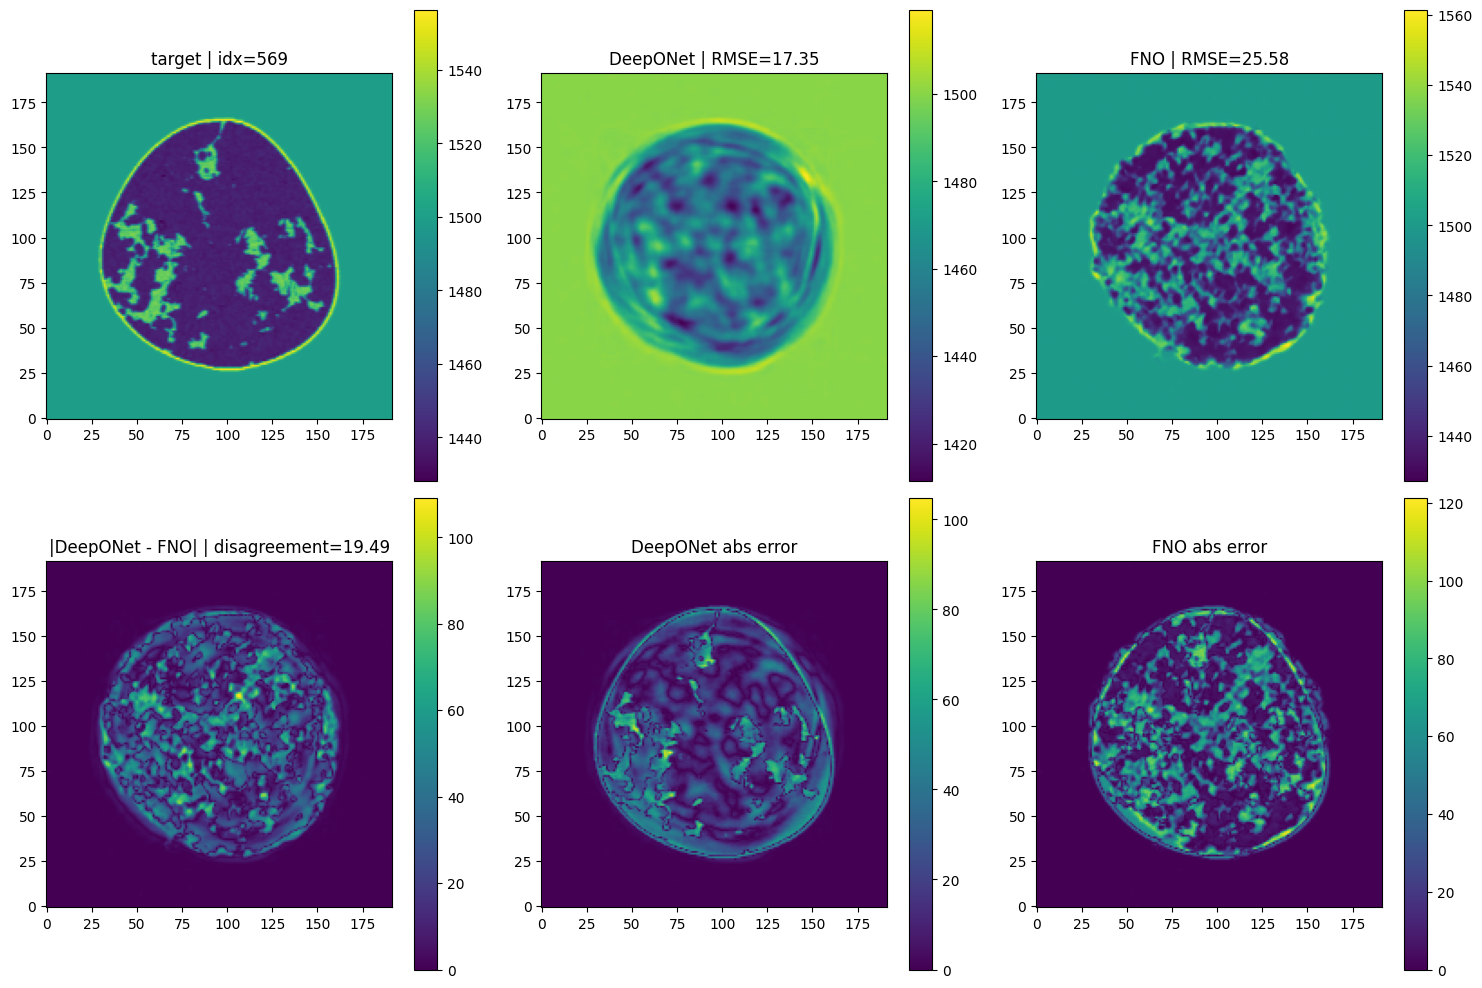

/workspace/usct_dataset_v2/test/sample_00569.npz


,index,path,deepo_mse,deepo_rmse,deepo_relative_l2,deepo_psnr,fno_mse,fno_rmse,fno_relative_l2,fno_psnr,...,c_mean,c_std,c_range,amp_mean,amp_std,amp_max,amp_p95,phase_mean,phase_std,x_scale
569,569,/workspace/usct_dataset_v2/test/sample_00569.npz,300.950562,17.347927,0.011693,20.979894,654.132751,25.576019,0.01724,17.608187,...,1483.276855,28.879292,128.202026,5501.840332,23440.330078,310586.3125,8693.171875,-0.060227,1.831374,6409.771973


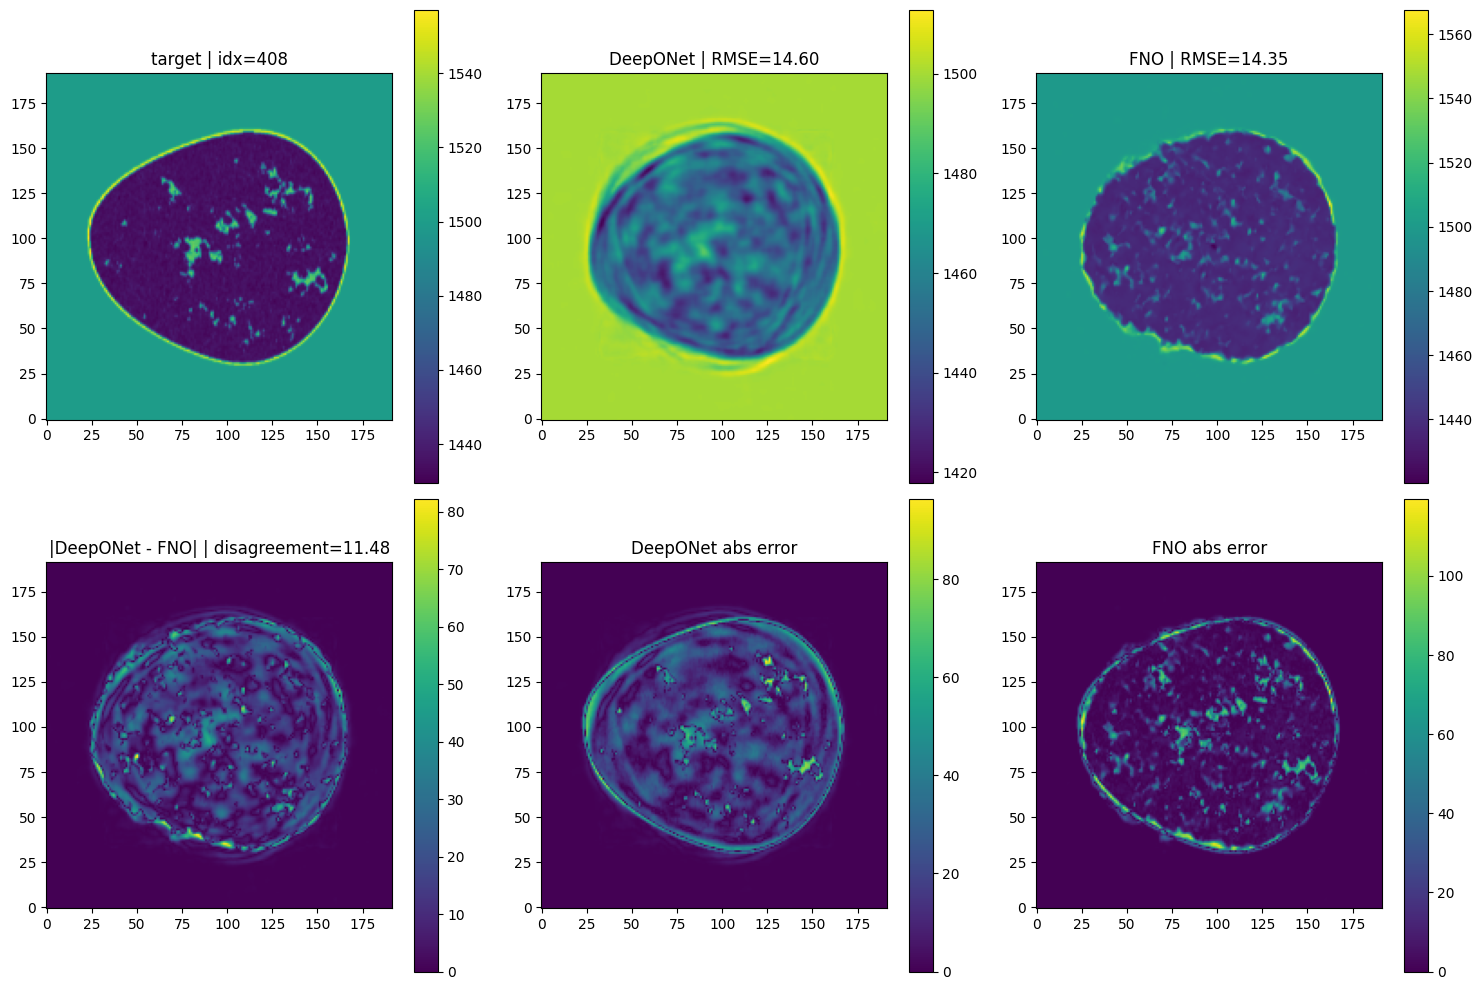

/workspace/usct_dataset_v2/test/sample_00408.npz


,index,path,deepo_mse,deepo_rmse,deepo_relative_l2,deepo_psnr,fno_mse,fno_rmse,fno_relative_l2,fno_psnr,...,c_mean,c_std,c_range,amp_mean,amp_std,amp_max,amp_p95,phase_mean,phase_std,x_scale
408,408,/workspace/usct_dataset_v2/test/sample_00408.npz,213.022263,14.595283,0.009874,22.480596,206.043594,14.354218,0.00971,22.625255,...,1477.888672,31.610836,127.473999,5643.916016,23537.021484,314055.46875,8366.983398,-0.040678,1.779388,6927.666016


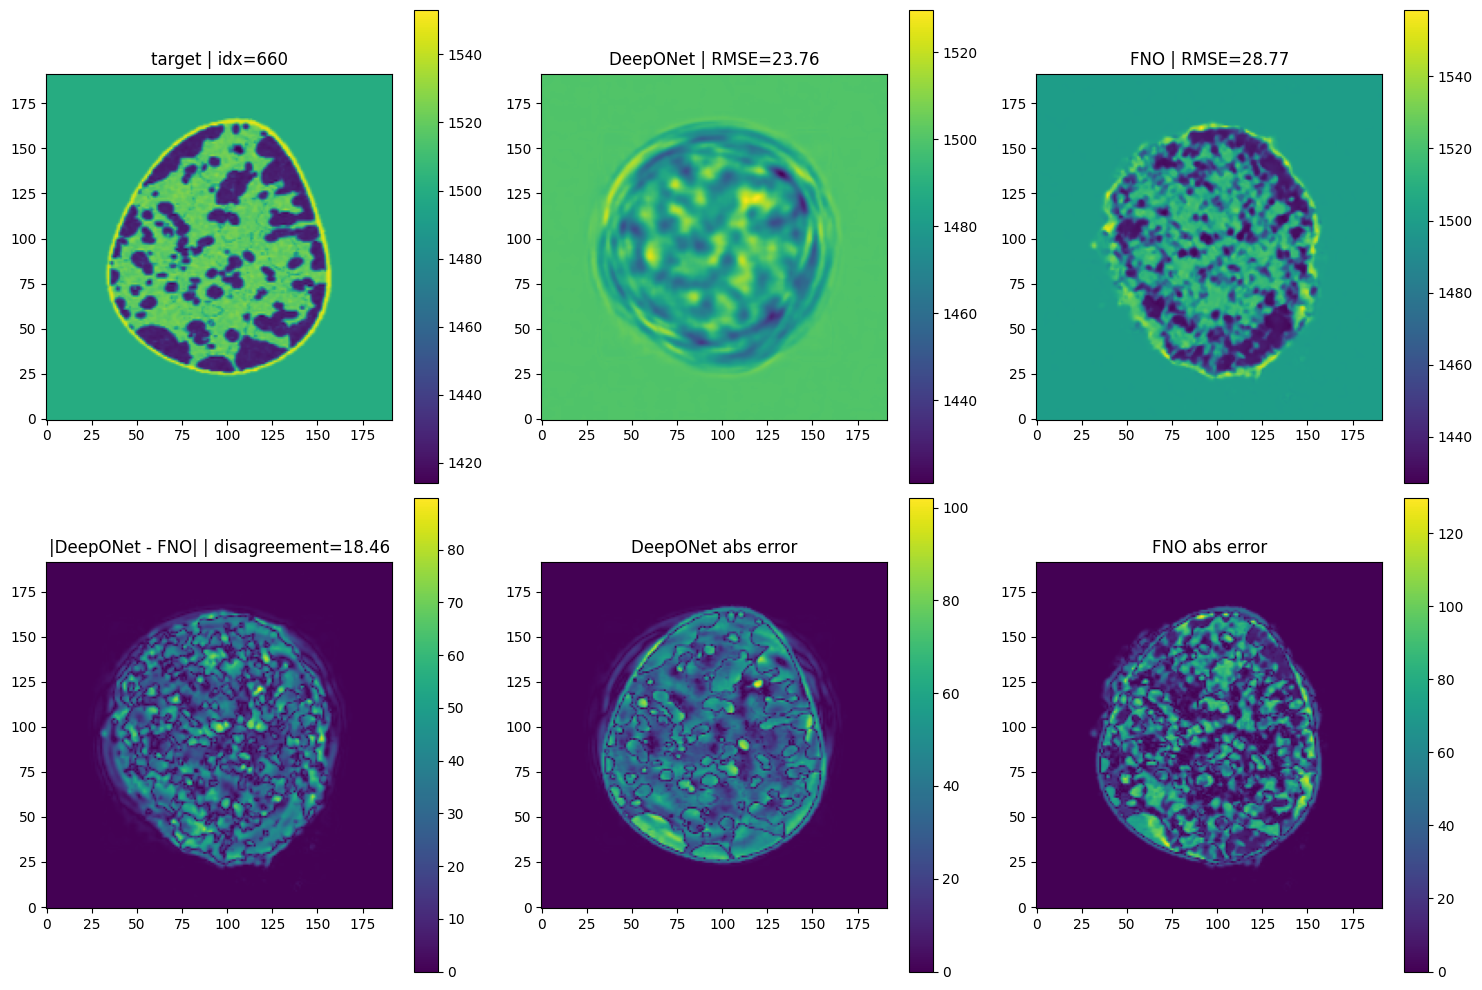

/workspace/usct_dataset_v2/test/sample_00660.npz


,index,path,deepo_mse,deepo_rmse,deepo_relative_l2,deepo_psnr,fno_mse,fno_rmse,fno_relative_l2,fno_psnr,...,c_mean,c_std,c_range,amp_mean,amp_std,amp_max,amp_p95,phase_mean,phase_std,x_scale
660,660,/workspace/usct_dataset_v2/test/sample_00660.npz,564.355469,23.756166,0.015892,18.249318,827.762268,28.770859,0.019247,16.58579,...,1494.627686,26.383081,139.031372,5447.31543,23701.080078,313951.8125,8815.298828,-0.110401,1.803323,6372.736816


In [24]:
def show_case(case_idx):
    item = predictions_test[case_idx]
    target = item["target_phys"]
    deepo = item["deepo_pred_phys"]
    fno_ = item["fno_pred_phys"]
    deepo_err = item["deepo_abs_err"]
    fno_err = item["fno_abs_err"]

    row = df_test.iloc[case_idx]

    fig, ax = plt.subplots(2, 3, figsize=(15, 10))

    im0 = ax[0, 0].imshow(target, origin="lower")
    ax[0, 0].set_title(f"target | idx={case_idx}")
    plt.colorbar(im0, ax=ax[0, 0])

    im1 = ax[0, 1].imshow(deepo, origin="lower")
    ax[0, 1].set_title(f"DeepONet | RMSE={row['deepo_rmse']:.2f}")
    plt.colorbar(im1, ax=ax[0, 1])

    im2 = ax[0, 2].imshow(fno_, origin="lower")
    ax[0, 2].set_title(f"FNO | RMSE={row['fno_rmse']:.2f}")
    plt.colorbar(im2, ax=ax[0, 2])

    im3 = ax[1, 0].imshow(np.abs(deepo - fno_), origin="lower")
    ax[1, 0].set_title(f"|DeepONet - FNO| | disagreement={row['disagreement_rmse']:.2f}")
    plt.colorbar(im3, ax=ax[1, 0])

    im4 = ax[1, 1].imshow(deepo_err, origin="lower")
    ax[1, 1].set_title("DeepONet abs error")
    plt.colorbar(im4, ax=ax[1, 1])

    im5 = ax[1, 2].imshow(fno_err, origin="lower")
    ax[1, 2].set_title("FNO abs error")
    plt.colorbar(im5, ax=ax[1, 2])

    plt.tight_layout()
    plt.show()

    print(item["path"])
    display(row.to_frame().T)

example_indices = [
    int(deeo_biggest_wins.iloc[0]["index"]),
    int(fno_biggest_wins.iloc[0]["index"]),
    int(hard_for_both.iloc[0]["index"]),
]

for idx in example_indices:
    show_case(idx)

## 9. Error vs target / measurement descriptors

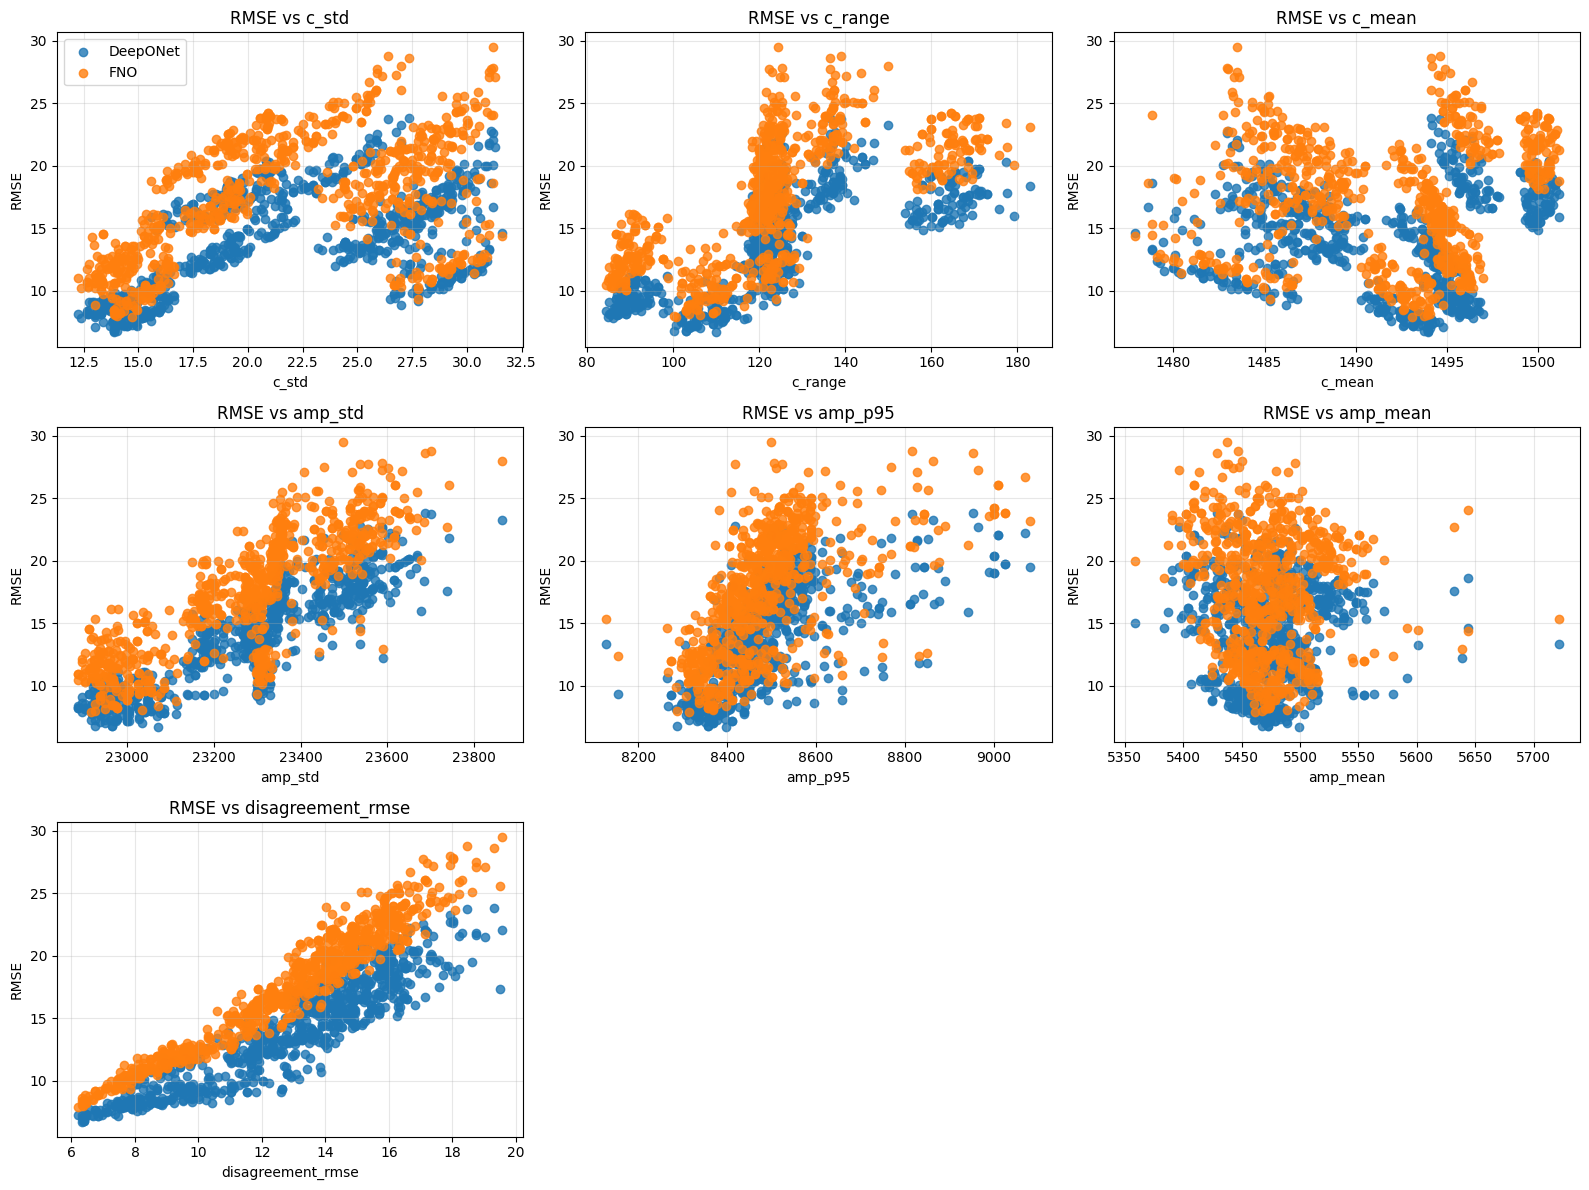

In [25]:
descriptor_cols = ["c_std", "c_range", "c_mean", "amp_std", "amp_p95", "amp_mean", "disagreement_rmse"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for ax, col in zip(axes, descriptor_cols):
    ax.scatter(df_test[col], df_test["deepo_rmse"], alpha=0.8, label="DeepONet")
    ax.scatter(df_test[col], df_test["fno_rmse"], alpha=0.8, label="FNO")
    ax.set_xlabel(col)
    ax.set_ylabel("RMSE")
    ax.set_title(f"RMSE vs {col}")
    ax.grid(True, alpha=0.3)

axes[0].legend()
for ax in axes[len(descriptor_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [26]:
corr_deepo = df_test[["deepo_rmse", "c_std", "c_range", "c_mean", "amp_std", "amp_p95", "amp_mean", "disagreement_rmse"]].corr()["deepo_rmse"].drop("deepo_rmse")
corr_fno = df_test[["fno_rmse", "c_std", "c_range", "c_mean", "amp_std", "amp_p95", "amp_mean", "disagreement_rmse"]].corr()["fno_rmse"].drop("fno_rmse")

corr_table = pd.DataFrame({
    "corr_with_deepo_rmse": corr_deepo,
    "corr_with_fno_rmse": corr_fno,
})

corr_table.sort_values("corr_with_deepo_rmse", ascending=False)

,corr_with_deepo_rmse,corr_with_fno_rmse
disagreement_rmse,0.923758,0.969719
amp_std,0.884443,0.819165
c_range,0.723923,0.654646
amp_p95,0.653211,0.609070
c_std,0.581269,0.526001
c_mean,0.021733,0.056251
amp_mean,0.005751,-0.056709


In [27]:
df_test["c_std_bin"] = pd.qcut(df_test["c_std"], q=4, duplicates="drop")
df_test.groupby("c_std_bin")[["deepo_rmse", "fno_rmse", "deepo_relative_l2", "fno_relative_l2"]].mean()

,deepo_rmse,fno_rmse,deepo_relative_l2,fno_relative_l2
c_std_bin,,,,
"(12.251000000000001, 16.247]",8.851853,11.683758,0.005922,0.007817
"(16.247, 20.85]",14.745855,18.502434,0.009849,0.012359
"(20.85, 26.911]",16.391519,20.467520,0.010980,0.013712
"(26.911, 31.611]",15.339606,18.792734,0.010329,0.012654


In [28]:
df_test["amp_std_bin"] = pd.qcut(df_test["amp_std"], q=4, duplicates="drop")
df_test.groupby("amp_std_bin")[["deepo_rmse", "fno_rmse", "deepo_relative_l2", "fno_relative_l2"]].mean()

,deepo_rmse,fno_rmse,deepo_relative_l2,fno_relative_l2
amp_std_bin,,,,
"(22887.341, 23138.065]",8.755372,11.551183,0.005859,0.007730
"(23138.065, 23303.925]",13.109853,16.740389,0.008794,0.011228
"(23303.925, 23433.662]",15.140244,18.812645,0.010180,0.012648
"(23433.662, 23864.734]",18.315137,22.332404,0.012243,0.014929


## 10. Quick textual conclusions (numbers only)

In [29]:
print("DeepONet mean RMSE:", float(df_test["deepo_rmse"].mean()))
print("FNO mean RMSE:", float(df_test["fno_rmse"].mean()))
print("DeepONet median RMSE:", float(df_test["deepo_rmse"].median()))
print("FNO median RMSE:", float(df_test["fno_rmse"].median()))
print("DeepONet win rate:", float((df_test["winner_by_rmse"] == "DeepONet").mean()))
print("FNO win rate:", float((df_test["winner_by_rmse"] == "FNO").mean()))
print("Mean disagreement RMSE:", float(df_test["disagreement_rmse"].mean()))
print("95th percentile DeepONet RMSE:", float(df_test["deepo_rmse"].quantile(0.95)))
print("95th percentile FNO RMSE:", float(df_test["fno_rmse"].quantile(0.95)))

DeepONet mean RMSE: 13.830151301026344
FNO mean RMSE: 17.359154997467996
DeepONet median RMSE: 13.883546829223633
FNO median RMSE: 17.755871772766113
DeepONet win rate: 0.99875
FNO win rate: 0.00125
Mean disagreement RMSE: 12.666473457217217
95th percentile DeepONet RMSE: 20.137732791900635
95th percentile FNO RMSE: 24.634772491455074


## 11. Save artifacts

In [30]:
RUN_DIR = Path("/workspace/reference_points") / CFG["run_name"]
RUN_DIR.mkdir(parents=True, exist_ok=True)

summary.to_csv(RUN_DIR / "summary_table.csv")
df_test.to_csv(RUN_DIR / "per_sample_metrics.csv", index=False)

with open(RUN_DIR / "summary_table.json", "w", encoding="utf-8") as f:
    json.dump(summary.to_dict(), f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "config": CFG,
            "stats": stats,
            "S": int(S),
            "R": int(R),
            "H": int(H),
            "W": int(W),
            "dx": [float(v) for v in dx],
            "freq_hz": float(freq_hz),
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

with open(RUN_DIR / "best_deepo_cases.json", "w", encoding="utf-8") as f:
    json.dump(best_deepo.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "worst_deepo_cases.json", "w", encoding="utf-8") as f:
    json.dump(worst_deepo.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "best_fno_cases.json", "w", encoding="utf-8") as f:
    json.dump(best_fno.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "worst_fno_cases.json", "w", encoding="utf-8") as f:
    json.dump(worst_fno.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "deepo_biggest_wins.json", "w", encoding="utf-8") as f:
    json.dump(deeo_biggest_wins.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "fno_biggest_wins.json", "w", encoding="utf-8") as f:
    json.dump(fno_biggest_wins.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "hard_for_both.json", "w", encoding="utf-8") as f:
    json.dump(hard_for_both.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print("saved to:", RUN_DIR)
print("per-sample metrics:", RUN_DIR / "per_sample_metrics.csv")

saved to: /workspace/reference_points/analysis_deeponet_fno
per-sample metrics: /workspace/reference_points/analysis_deeponet_fno/per_sample_metrics.csv
